# Modelo Híbrido
El objetivo de este notebook es combinar los modelos que hicimos hasta ahroa en un solo modelo y evaluar la performance.

Este modelo:
1. Clasifica cada muestra en normal (0) u outlier (1)
2. En caso de ser normal, estima el precio del alquiler usando el modelo optimizado para muestras normales
3. En caso de ser outlier, estima el precio usando el modelo optimizado para outliers

In [2]:
import pandas as pd
from sklearn import set_config

from src.config import TREE_BASED_CONFIG_NORMAL
from src.model_evaluation import evaluate_models_cv
from src.models.base_models import get_base_xgboost
from src.models.hybrid import get_hybrid_model
from src.models.xgboost_models import get_xgboost_full
from src.pipeline import build_base_pipeline, build_feature_pipeline, build_target_pipeline
from src.plots import plot_cv_results
from src.constants import DEV_SET_CLEAN_PATH, TARGET

set_config(transform_output="pandas")

In [3]:
# usamos dataset completo !!
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [4]:
feature_pipeline = build_feature_pipeline(TREE_BASED_CONFIG_NORMAL)
target_pipeline = build_target_pipeline(TREE_BASED_CONFIG_NORMAL)

## Definimos modelos a comparar

### Modelo base sin preprocesar

In [5]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

base_preprocessor = build_base_pipeline(numeric_cols, categorical_cols)
base_xgboost = get_base_xgboost(base_preprocessor)

### Modelo base preprocesado

In [6]:
base_xgboost_preprocessed = get_base_xgboost(feature_pipeline)

### Mejor XGBoost

In [7]:
best_xgboost = get_xgboost_full()

### Modelo Híbrido

In [8]:
hybrid_xgboost = get_hybrid_model()

# Comparación final con CV

In [9]:
models = {
    "Base": base_xgboost,
    "Base (preprocesado)": base_xgboost_preprocessed,
    "Mejor XGBoost": best_xgboost,
    "Modelo Híbrido": hybrid_xgboost,
}

In [10]:
results = evaluate_models_cv(
    models,
    X,
    y,
    feature_pipeline=None, # los modelos ya tienen pipeline,
    target_pipeline=None,
    n_splits=5,
    random_state=42
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando Base...
  ✓ MAE: 95,952 ± 2,562
  ✓ RMSE: 438,114 ± 49,773

Entrenando Base (preprocesado)...
  ✓ MAE: 94,263 ± 1,970
  ✓ RMSE: 432,742 ± 44,098

Entrenando Mejor XGBoost...
  ✓ MAE: 56,488 ± 1,787
  ✓ RMSE: 397,878 ± 40,828

Entrenando Modelo Híbrido...
  ✓ MAE: 29,046 ± 1,983
  ✓ RMSE: 427,498 ± 49,106



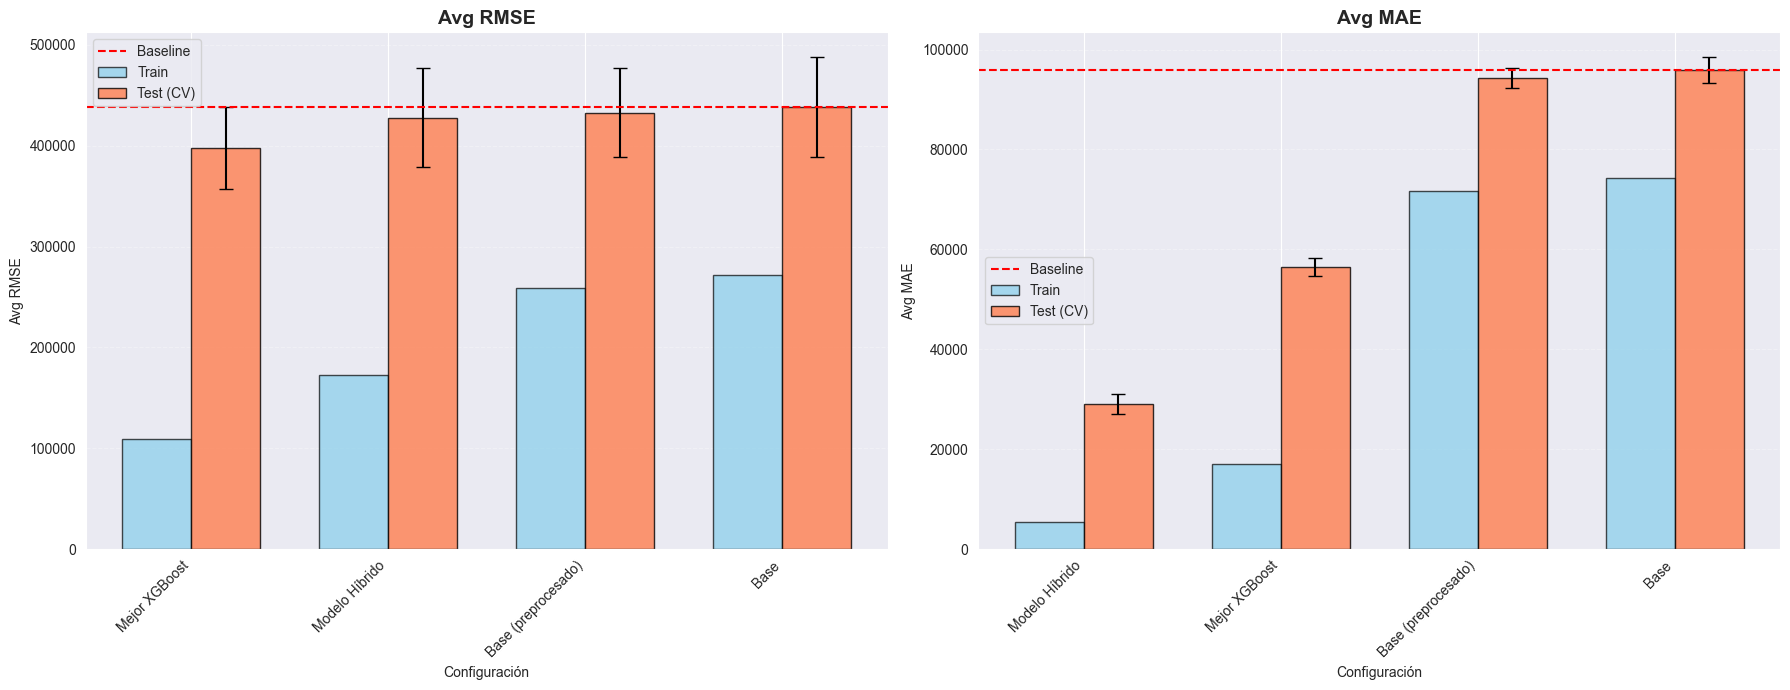

In [12]:
plot_cv_results(results, baseline_name="Base", vertical_layout=False)